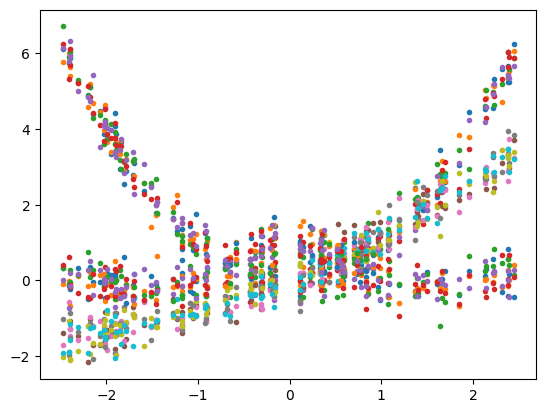

In [266]:
from matplotlib import pyplot as plt
import numpy as np
import torch


# Define the activation functions
def sin_activation(x):
    return np.sin(x)

def square_activation(x):
    return x**2

def bent_activation(x):
    return (np.sqrt(x ** 2 + 1) - 1) / 2 + x

def cos_activation(x):
    return np.cos(x)

def sinc_activation(x):
    return np.sinc(x)

task_list = [
    square_activation,
    square_activation,
    square_activation,
    square_activation,
    square_activation,
    bent_activation,
    bent_activation,
    bent_activation,
    bent_activation,
    bent_activation,
    sinc_activation,
    sinc_activation,
    sinc_activation,
    sinc_activation,
    sinc_activation,
]

input_dim = 1

# generate data
np.random.seed(0)
x_train = (np.random.rand(100, input_dim) - 0.5) * 5.0
x_valid = (np.random.rand(50, input_dim) - 0.5) * 5.0

delta_mag = 0.33

y_train = np.zeros([x_train.shape[0], 0])
y_valid = np.zeros([x_valid.shape[0], 0])
for task in task_list:
    y_train = np.hstack([y_train, task(x_train) + np.random.randn(x_train.shape[0], x_train.shape[1]) * delta_mag])
    y_valid = np.hstack([y_valid, task(x_valid) + np.random.randn(x_valid.shape[0], x_valid.shape[1]) * delta_mag])

x_train = torch.tensor(x_train).float()
y_train = torch.tensor(y_train).float()

x_valid = torch.tensor(x_valid).float()
y_valid = torch.tensor(y_valid).float()

for i in range(y_train.shape[1]):
    plt.plot(x_train, y_train[:, i], '.')

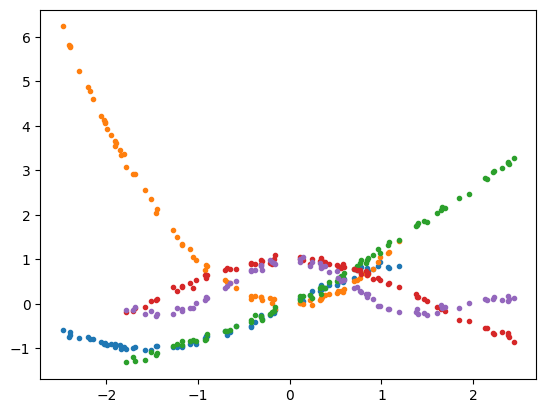

In [374]:
from matplotlib import pyplot as plt
import numpy as np
import torch


# Define the activation functions
def sin_activation(x):
    return np.sin(x)

def square_activation(x):
    return x**2

def bent_activation(x):
    return (np.sqrt(x ** 2 + 1) - 1) / 2 + x

def cos_activation(x):
    return np.cos(x)

def sinc_activation(x):
    return np.sinc(x)

task_list = [
    sin_activation,
    square_activation,
    bent_activation,
    cos_activation,
    sinc_activation,
]

# task_list = [
#     square_activation,
#     bent_activation,
#     sinc_activation,
# ]

input_dim = 1
extrapolate = True
full_tasks = []

# generate data
np.random.seed(0)
x_train = (np.random.rand(100, input_dim) - 0.5) * 5.0
x_valid = (np.random.rand(100, input_dim) - 0.5) * 5.0

delta_mag = 0.05

y_train = np.zeros([x_train.shape[0], 0])
y_valid = np.zeros([x_valid.shape[0], 0])
for task in task_list:
    y_train = np.hstack([y_train, task(x_train) + np.random.randn(x_train.shape[0], x_train.shape[1]) * delta_mag])
    y_valid = np.hstack([y_valid, task(x_valid) + np.random.randn(x_valid.shape[0], x_valid.shape[1]) * delta_mag])

missing_frac = 0.20
for i, _ in enumerate(task_list):
    if extrapolate:
        if np.random.rand() < 0.5:
            lo_pct = 0  # start at left boundary
        else:
            lo_pct = 1 - missing_frac  # start at right boundary
    else:
        lo_pct = np.random.rand() * (1-missing_frac)
    hi_pct = lo_pct + missing_frac
    lo, hi = np.percentile(x_train, [lo_pct*100, hi_pct*100])
    x_in = (x_train >= lo) & (x_train <= hi)
    if i in full_tasks:
        x_in = np.zeros(0, dtype=bool)
    y_train[x_in.flatten(), i] = np.nan

x_train = torch.tensor(x_train).float()
y_train = torch.tensor(y_train).float()

x_valid = torch.tensor(x_valid).float()
y_valid = torch.tensor(y_valid).float()

for i in range(y_train.shape[1]):
    plt.plot(x_train, y_train[:, i], '.')

In [330]:
import torch
import torch.nn as nn
import torch.nn.functional as F
 
 
class SharedMLP(nn.Module):
    def __init__(self, input_size, hidden_size, n_tasks, n_outputs, beta = 0):
        super().__init__()
        assert 0 <= beta < 1
        self.input_size = input_size
 
        h_sizes = [self.input_size] + [hidden_size for _ in range(n_tasks)] + [n_outputs]
        self.hidden = nn.ModuleList()
 
        for k in range(len(h_sizes)-1):
          self.hidden.append(
              nn.Linear(
                  h_sizes[k],
                  h_sizes[k+1]
              )
          )
 
        self.relu = nn.ReLU()
 
    def forward(self, x):
      for layer in self.hidden[:-1]:
        x = layer(self, x)
        x = self.relu(x)
        x = self.dropout(x)
 
        return self.hidden[-1](x)
 
 
class TaskSpecificMLP(nn.Module):
    def __init__(self, input_size, hidden_sizes, n_tasks):
        super(TaskSpecificMLP, self).__init__()
        self.task_nets = nn.ModuleList()
        for _ in range(n_tasks):
            layers = []
            sizes = [input_size] + list(hidden_sizes)
            for i in range(len(sizes) - 1):
                layers.append(nn.Linear(sizes[i], sizes[i+1]))
                layers.append(nn.ReLU())
            self.task_nets.append(nn.Sequential(*layers))
        
        # Separate task heads
        self.task_heads = nn.ModuleList([nn.Linear(hidden_sizes[-1], 1) for _ in range(n_tasks)])
        
        # Apply consistent weight initialization
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            torch.manual_seed(0)  # Set seed for reproducibility
            nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                nn.init.zeros_(m.bias)

    def forward(self, x):
        shared_outputs = [net(x) for net in self.task_nets]
        return torch.cat([head(out) for head, out in zip(self.task_heads, shared_outputs)], dim=1)


class SoftSharingMLP(nn.Module):
    def __init__(self, input_size, hidden_size, n_tasks, enable_sharing=True):  # Set beta = 0 for comparison with single task
        super().__init__()
        self.model = TaskSpecificMLP(input_size, hidden_size, n_tasks)
        self.enable_sharing = enable_sharing
        self.n_tasks = n_tasks
        self.criterion = nn.MSELoss()  # Ensure MSE loss matches the single-task case
 
    def get_param_groups(self):
        param_groups = []
        # Gather weights of each task for soft-sharing regularization
        for out in zip(*[n.named_parameters() for n in self.model.task_nets]):
            if 'weight' in out[0][0]:
                param_groups.append([out[i][1] for i in range(len(out))])
        return param_groups
 
    def soft_loss(self):
        if not self.enable_sharing:
            return torch.tensor(0.0)
        param_groups = self.get_param_groups()
        soft_sharing_loss = torch.tensor(0.0)
        for params in param_groups:
            soft_sharing_loss += torch.norm(params[0] - params[1], p='fro')
        return soft_sharing_loss  # Apply regularization
 
    def forward(self, x):
        outputs = self.model(x)
        return outputs
    
    
class MultiTaskMSELoss(nn.Module):
    def __init__(self, reduction='mean'):
        super().__init__()
        if reduction not in ['mean', 'sum', 'none']:
            raise ValueError('Invalid reduction method')
        self.reduction = reduction

    def forward(self, input, target):
        # Mask out the NaN values in the targets
        mask = ~torch.isnan(target)

        # Compute the mean squared error, ignoring NaN values
        mse = F.mse_loss(input[mask], target[mask], reduction=self.reduction)

        return mse

In [368]:
from torch import optim


model = SoftSharingMLP(1, (64, 64, 64, ), len(task_list), enable_sharing=True)

# criterion = nn.MSELoss()
criterion = MultiTaskMSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-2)

beta = 1e6

max_epochs = int(1e4)

patience_interval = 100
last_best = (0, np.inf)
model.train()
for epoch in range(max_epochs):
    optimizer.zero_grad()
    outputs = model(x_train)
    loss = criterion(outputs, y_train)
    sharing_loss = model.soft_loss()
    total_loss = loss + beta * sharing_loss
    total_loss.backward()
    optimizer.step()

    if loss.item() < last_best[1]:
        last_best = (epoch, loss.item())

    if (epoch+1) % 100 == 0:
        with torch.no_grad():
            outputs = model(x_valid)
            valid_loss = criterion(outputs, y_valid)
        print(f'Epoch {epoch+1}, MSE: {loss.item():.4f}, Sharing: {sharing_loss.item():.4f}, ValMSE: {valid_loss.item():.4f}')
    
    if epoch - last_best[0] > patience_interval:
        print('Patience expired...')
        break

Epoch 100, MSE: 0.0385, Sharing: 0.0912, ValMSE: 0.0673
Epoch 200, MSE: 0.0098, Sharing: 0.0830, ValMSE: 0.0319
Epoch 300, MSE: 0.0048, Sharing: 0.0967, ValMSE: 0.0233
Epoch 400, MSE: 0.0028, Sharing: 0.0816, ValMSE: 0.0196
Epoch 500, MSE: 0.0017, Sharing: 0.0908, ValMSE: 0.0167
Epoch 600, MSE: 0.0011, Sharing: 0.1114, ValMSE: 0.0148
Epoch 700, MSE: 0.0007, Sharing: 0.0920, ValMSE: 0.0177
Epoch 800, MSE: 0.0007, Sharing: 0.0792, ValMSE: 0.0181
Epoch 900, MSE: 0.0004, Sharing: 0.0874, ValMSE: 0.0195
Epoch 1000, MSE: 0.0003, Sharing: 0.0850, ValMSE: 0.0217
Epoch 1100, MSE: 0.0018, Sharing: 0.0824, ValMSE: 0.0235
Epoch 1200, MSE: 0.0003, Sharing: 0.0837, ValMSE: 0.0221
Epoch 1300, MSE: 0.0006, Sharing: 0.0772, ValMSE: 0.0255
Epoch 1400, MSE: 0.0003, Sharing: 0.0847, ValMSE: 0.0240
Epoch 1500, MSE: 0.0003, Sharing: 0.1024, ValMSE: 0.0263
Patience expired...


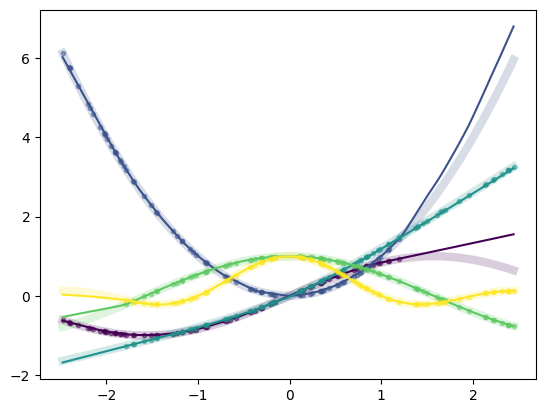

In [369]:
from matplotlib import cm

model.eval()

x_arr = torch.linspace(x_train.min(), x_train.max(), 101)
with torch.no_grad():
    output = model(x_arr.unsqueeze(1))
idx = np.argsort(x_train.numpy().flatten())
colors = cm.viridis(np.linspace(0, 1, y_train.shape[1]))
for i in range(y_train.shape[1]):
    plt.plot(x_train[idx], y_train[idx, i], '.', c=colors[i], alpha=0.5)
    plt.plot(x_arr, output.numpy()[:, i], '-', c=colors[i])
    plt.plot(x_arr, task_list[i](x_arr), '-', c=colors[i], lw=6, alpha=0.2, zorder=-1)

[0.00649918 0.02312511 0.01694275 0.00077916 0.00072808]
[0.23389004 0.2663378  0.01903073 0.05765316 0.02785631]


(0.0, 0.5)

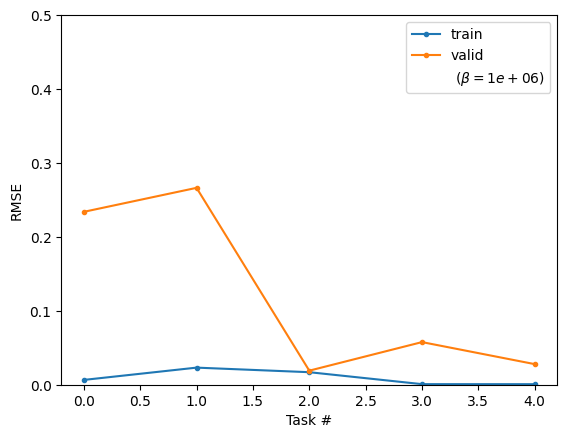

In [370]:
for (l, xt, yt) in [('train', x_train, y_train), ('valid', x_valid, y_valid)]:
    with torch.no_grad():
        out = model(xt)
    losses = np.zeros(len(task_list))
    for i in range(model.n_tasks):
        losses[i] = np.sqrt( criterion(out[:, i], yt[:, i]).mean().item() )
    plt.plot(losses, '.-', label=l)
    print(losses)
plt.plot(np.nan, np.nan, 'w.', label=f' $(\\beta = {beta:.0e}$)')
plt.legend()
plt.xlabel('Task #')
plt.ylabel('RMSE')
plt.ylim(0, 0.50)